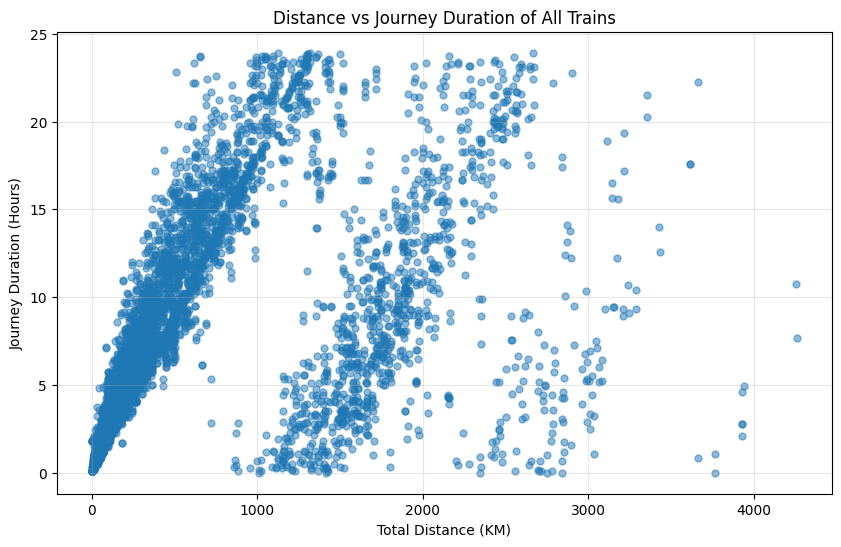

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


# Load dataset
df = pd.read_csv("Dataset1.csv")

df = df.sort_values(["Train_No", "SN"])


# Convert time

df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S"
)


# Create train-wise data

train_data = df.groupby("Train_No").agg(
    Total_Distance=("Distance", "max"),
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last")
).reset_index()


# Handle next day journey

train_data.loc[
    train_data["End_Time"] < train_data["Start_Time"],
    "End_Time"
] += pd.Timedelta(days=1)


# Journey duration

train_data["Journey_Hours"] = (
    train_data["End_Time"] - train_data["Start_Time"]
).dt.total_seconds()/3600


# Plot

plt.figure(figsize=(10,6))

plt.scatter(
    train_data["Total_Distance"],
    train_data["Journey_Hours"],
    alpha=0.5,
    s=25
)

plt.xlabel("Total Distance (KM)")
plt.ylabel("Journey Duration (Hours)")

plt.title("Distance vs Journey Duration of All Trains")

plt.grid(alpha=0.3)

plt.show()